In [ ]:
import os
import pandas as pd
import networkx as nx 
import matplotlib.pyplot as plt
import torch
from networkx.algorithms.community import modularity
from community import community_louvain
import numpy as np

In [30]:
def clean_gt_file_names(importance_ranking):

    """ Gets torch files of ground truth and replaces any old twitter
        usernames with the new ones to match the df_data """

    # Load the DataFrame with member data
    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')

    # Fill NA values in 'new_twitter_name' with values from 'twitter_name'
    members['new_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    # Create a dictionary mapping from the old Twitter names to the new Twitter names
    name_mapping = dict(zip(members['twitter_name'], members['new_twitter_name']))

    # Initialize a new dictionary to hold the updated importance ranking
    updated_importance_ranking = {}

    # Update the dictionary keys
    for old_name, value in importance_ranking.items():
        # Get the new Twitter name if available, otherwise keep the old name
        new_name = name_mapping.get(old_name, old_name)
        updated_importance_ranking[new_name] = value

    # Assign the updated dictionary back to importance_ranking
    return updated_importance_ranking

# Print the updated importance ranking to check
# importance_ranking = torch.load('01_normalized_congress_member_to_affiliation_score.pth')


In [ ]:
def assign_strength(df, inflection_point, party_flag):
    """ Assigns 'strong' or 'weak' based on the affiliation score. """
    if party_flag == 'R':
        return 'strong' if df['affiliation_score'] >= inflection_point else 'weak'
    else:  # 'D'
        return 'strong' if df['affiliation_score'] <= inflection_point else 'weak'

In [32]:
def build_bipartite_network(df_data):

    """ Builds directed network using politicians and their followings as nodes
    and directed edges based on if one node follows the other. Used for finding importance
    of websites to filter network """

    G = nx.DiGraph()

    # Add edges based on the politicians and the people they follow
    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']
        following_list = row['following']  # List of people the politician follows
        
        # Add the politician as a node
        G.add_node(politician, party=row['party'])
        
        # Add edges for each person the politician follows
        for followee in following_list:
            G.add_node(followee)  # Add the followed account as a node
            G.add_edge(politician, followee)  # Directed edge from politician to followed account
    
    return G

In [ ]:
def read_data(num_nodes=-1):

    """ Reads data of politician, their party and who they follow into df_data """

    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')
    members['current_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    df_data = pd.DataFrame()
    df_data[['current_twitter_name','party']] = members[['current_twitter_name','party']].copy()
    if num_nodes != -1:
        df_data = df_data.head(num_nodes)

    following_data = []
    
    for twitter_name in df_data['current_twitter_name']:
        filename = f"twitterExport_{twitter_name}_Following.csv"
        filepath = os.path.join('raw_data/raw_data/following_data_raw', filename)

        if os.path.exists(filepath):
            followed_users = pd.read_csv(filepath)['user_name'].tolist()
        else:
            followed_users = []
        
        following_data.append(followed_users)

    df_data['complete_following'] = following_data
    df_data = df_data[df_data['complete_following'].apply(lambda x: x != [])]

    # Convert the list of all current twitter names to a set for faster lookup
    current_names_set = set(df_data['current_twitter_name'].values)

    # Filter out following names that also appear in df_data['current_twitter_name']
    filtered_following_data = []
    for follow_list in df_data['complete_following']:
        filtered_list = [name for name in follow_list if name not in current_names_set]
        filtered_following_data.append(filtered_list)

    df_data['following'] = filtered_following_data
    df_data = df_data[df_data['following'].apply(lambda x: x != [])]
    
    
    importance_ranking = clean_gt_file_names(torch.load('01_normalized_congress_member_to_affiliation_score.pth',weights_only=False))
    df_data['affiliation_score'] = df_data['current_twitter_name'].map(importance_ranking)
    df_data['strength'] = df_data.apply(lambda x: assign_strength(x, 0.75 if x['party'] == 'R' else -0.75, x['party']), axis=1)
    republican_df = df_data[df_data['party'] == "R"]
    democratic_df = df_data[df_data['party'] == "D"]
    
    return df_data, republican_df, democratic_df

In [61]:
def degree_lower_2_remover(df_data,G_bipartite):
    degree_centrality = {node: G_bipartite.degree(node) for node in G_bipartite.nodes()}
    # Filtering nodes based on threshold
    filtered_followees = {node for node, score in degree_centrality.items() if score >= 2}
    df_data['following'] = df_data['following'].apply(lambda followings: [f for f in followings if f in filtered_followees])


In [ ]:
def degree_lower_n_remover(df_data,G_bipartite,n):
    degree_centrality = {node: G_bipartite.degree(node) for node in G_bipartite.nodes()}
    # Filtering nodes based on threshold
    filtered_followees = {node for node, score in degree_centrality.items() if score >= n}
    df_data['following'] = df_data['following'].apply(lambda followings: [f for f in followings if f in filtered_followees])


In [62]:
def classify_communities(alignment):
    ratio_list = []
    community_label = {}
    for community_id, parties_total in alignment.items():
        ratio = parties_total['R']/(parties_total['R']+parties_total['D'])
        ratio_list.append(ratio)

    if ratio_list[0]>ratio_list[1]:
        Republican = 1
        Democrat = 2
    else:
        Republican = 2
        Democrat = 1

    community_label[Republican] = 'Republican'
    community_label[Democrat] = 'Democrat' 
    # print(ratio_list, community_label)
    return community_label
    

In [63]:
def merge_n_communities_by_edge_count(G, communities, no_communities):
    """Merge a list of communities into exactly n_communities based on the edge counts between them.

    Args:
        G (networkx.Graph): The graph from which the communities are derived.
        communities (list of set): List of communities to merge, where each community is a set of nodes.
        no_communities (int): Desired number of communities after merging.

    Returns:
        list of set: Communities merged based on edge connectivity.
    """
    
    if len(communities) < no_communities:
        raise ValueError("The number of initial communities must be at least equal to the desired number of final communities.")

    # Convert frozensets or other iterables to sets if necessary
    communities = [set(community) for community in communities]

    # Sort communities by size in descending order
    communities = sorted(communities, key=len, reverse=True)

    # Start with the largest communities as determined by 'no_communities'
    largest_communities = communities[:no_communities]
    remaining_communities = communities[no_communities:]

    # Function to count edges between two sets of nodes
    def count_edges_between(set1, set2):
        return sum(1 for node in set1 if set(G.neighbors(node)) & set2)

    # Merge remaining communities into the largest based on edge counts
    for community in remaining_communities:
        max_edges = -1
        best_target_idx = -1

        # Determine which of the largest communities this should merge with
        for i, large_community in enumerate(largest_communities):
            edge_count = count_edges_between(community, large_community)
            if edge_count > max_edges:
                max_edges = edge_count
                best_target_idx = i

        # Merge the community into the best matching largest community
        largest_communities[best_target_idx].update(community)
    return largest_communities


In [ ]:
# NEW VERSION CHECK IF WORKS AND THEN TRY IMPLEMENT THE OTHERS

def louvain_two_communities(G):

    """ Run the Louvain algorithm to detect communities """

    partition = community_louvain.best_partition(G)


    initial_communities = {}
    for node, community in partition.items():
        if community not in initial_communities:
            initial_communities[community] = set()
        initial_communities[community].add(node)

    # Convert dictionary of communities into a list of sets
    communities_list = list(initial_communities.values())
    print(len(communities_list))

    # Step 3: Merge communities into two based on edge connectivity
    if len(communities_list) > 2:
        # communities = merge_communities_by_edge_count(G, communities_list)
        communities = merge_n_communities_by_edge_count(G, communities_list, 2)
        # communities = merge_communities_max_modularity(G, communities_list)
        # communities = merge_into_two_communities(communities_list)
    else:
        communities = communities_list
    # Create the final two-community split
    node_to_community = {}
    for node in communities[0]:
        node_to_community[node] = 1
    for node in communities[1]:
        node_to_community[node] = 2

    # Calculate modularity value
    try:
        mod_value = modularity(G, communities)
    except:
        mod_value = 0

    return communities, mod_value

In [65]:
def political_alignment(G, communities):
    """
    Analyze alignment with political parties for a given set of communities.

    Args:
        G (networkx.Graph): The graph from which the communities are derived, with nodes having a 'party' attribute.
        communities (list of set): List of communities, where each community is a set of nodes.

    Returns:
        dict: Dictionary containing the political alignment of each community.
    """
    # Initialize an alignment dictionary for all communities
    alignment = {}
    for idx, community in enumerate(communities, start=1):
        # Initialize party counts for the current community
        alignment[idx] = {'R': 0, 'D': 0}
        for node in community:
            if 'party' in G.nodes[node]:  # Check if the 'party' attribute exists
                party = G.nodes[node]['party']
                if party in alignment[idx]:  # Increment the party count if it's either 'R' or 'D'
                    alignment[idx][party] += 1
                else:  # Optional: initialize other party labels dynamically
                    alignment[idx][party] = 1

    return alignment


In [66]:
def build_network(df_data, k, hits, weighted):

    """ Builds network of politicians, with edges between them if they share k followers """

    G = nx.Graph()
    
    # Add nodes
    names = df_data['current_twitter_name'].tolist()

    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']        
        G.add_node(politician, party=row['party'])
    
    # Add edges based on shared following
    for i in range(len(df_data)):
        for j in range(i + 1, len(df_data)):
            # Get the sets of following of each politician
            # Uses the "important_following" column if we incorporate hits, otherwise defaults to the "following" column
            if hits:
                following_i = set(df_data.iloc[i]['important_following'])
                following_j = set(df_data.iloc[j]['important_following'])
            else:
                following_i = set(df_data.iloc[i]['following'])
                following_j = set(df_data.iloc[j]['following'])
            
            # Get the shared following
            shared_following = following_i.intersection(following_j)
            if len(shared_following) >= k:
                if weighted == False:
                    G.add_edge(names[i], names[j])
                else:
                    G.add_edge(names[i], names[j], weight=len(shared_following))
    
    return G

In [ ]:
def calculate_degree_ratio(node, graph, node_to_community):
    neighbors = list(graph.neighbors(node))
    if not neighbors:
        return 0  # Avoid division by zero if no neighbors
    # sign = 1 if graph.nodes[node]['party'] == 'R' else -1
    in_community = sum(1 for neighbor in neighbors if node_to_community.get(neighbor) == node_to_community.get(node))
    return in_community / len(neighbors)

def apply_degree_ratio(df_data, G, node_to_community):
    """ Applies the degree ratio to the dataframe """
    df_data['init_degree_ratio'] = df_data['current_twitter_name'].apply(lambda x: calculate_degree_ratio(x, G, node_to_community))

    df_data['degree_ratio'] = np.where(df_data['party'] == 'R', 
                                    df_data['init_degree_ratio'], 
                                    -df_data['init_degree_ratio'])
    df_data.drop(columns=['init_degree_ratio'], inplace=True)
    return df_data



In [ ]:
def calculate_neighbour_degree_ratio(node, graph, node_to_community):
    # Get neighbors of the node
    neighbors = list(graph.neighbors(node))
    print(node, neighbors)
    if not neighbors:
        return 0  # Return 0 if there are no neighbors to avoid division by zero
    
    # Sum of degree ratios for neighbors in the same community
    same_community_sum = sum(graph.nodes[neighbor]['degree_ratio'] for neighbor in neighbors 
                             if node_to_community[neighbor] == node_to_community[node])
    
    # Sum of degree ratios for all neighbors
    total_sum = sum(graph.nodes[neighbor]['degree_ratio'] for neighbor in neighbors)
    
    # Calculate the ratio
    return same_community_sum / total_sum if total_sum != 0 else 0


def apply_neighbour_degree_ratio(df_data, G, node_to_community):
    # Calculate and add 'neighbour_degree_ratio' to DataFrame
    # df_data['neighbour_degree_ratio'] = [calculate_neighbour_degree_ratio(node, G, node_to_community) for node in G.nodes()]
    df_data['init_neighbour_degree_ratio'] = df_data['current_twitter_name'].apply(lambda x: calculate_neighbour_degree_ratio(x, G, node_to_community))

    df_data['neighbour_degree_ratio'] = np.where(df_data['party'] == 'R', 
                                    df_data['init_neighbour_degree_ratio'], 
                                    -df_data['init_neighbour_degree_ratio'])
    df_data.drop(columns=['init_neighbour_degree_ratio'], inplace=True)
    return df_data


In [ ]:
df_data, republican_df, democratic_df = read_data(-1)
G_bipartite = build_bipartite_network(df_data)
degree_lower_2_remover(df_data, G_bipartite)
G = build_network(df_data, 26, False, True)
communities, mod_value = louvain_two_communities(G, 2)
node_to_community = {}
for node in communities[0]:
    node_to_community[node] = 1
for node in communities[1]:
    node_to_community[node] = 2

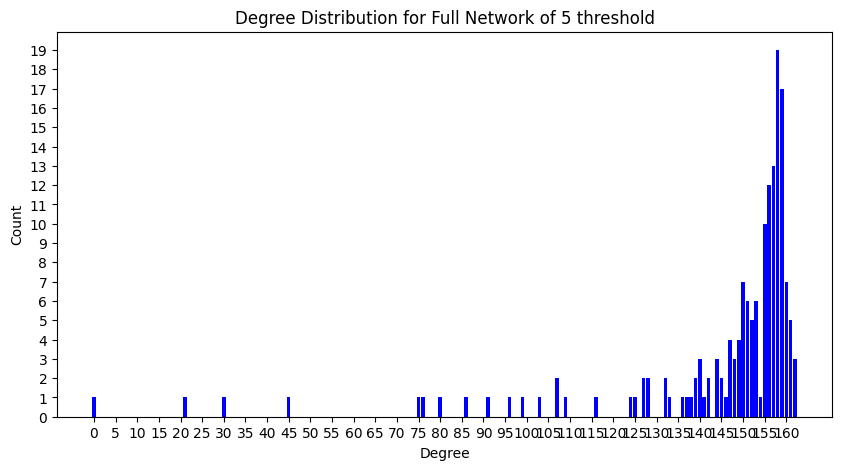

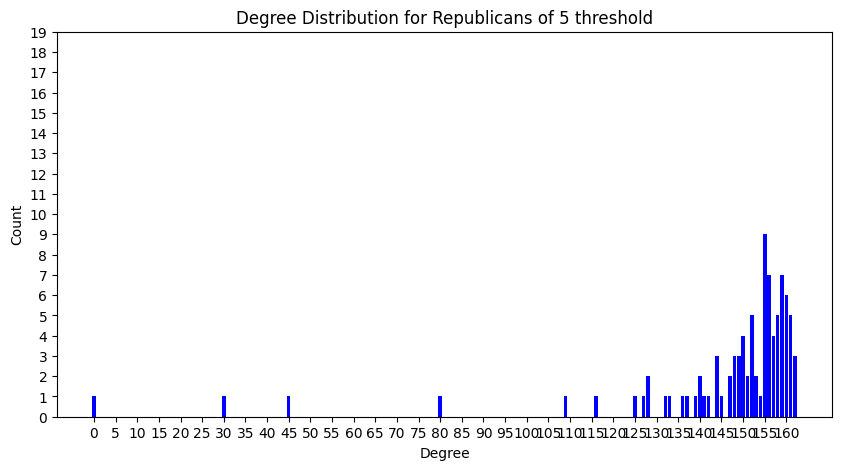

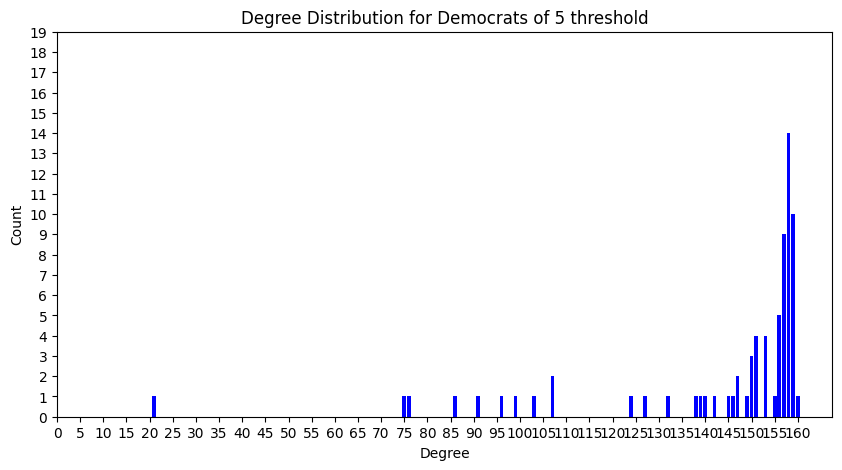

In [68]:

# Add a new column to the DataFrame for the affiliation score

# df_data
# print(df_data['degree_ratio'].unique())
import collections

# Get a list of degrees of all nodes in the graph
degrees = [degree for node, degree in G.degree()]
degrees_r = [degree for node, degree in G.degree() if G.nodes[node]['party'] == 'R']
degrees_d = [degree for node, degree in G.degree() if G.nodes[node]['party'] == 'D']

# Count the frequency of each degree value
degree_count = collections.Counter(degrees)
deg, cnt = zip(*degree_count.items())
plt.figure(figsize=(10, 5))  # Set the figure size as needed
plt.bar(deg, cnt, width=0.80, color='b')

plt.title("Degree Distribution for Full Network of 5 threshold")
plt.ylabel("Count")
plt.xlabel("Degree")
plt.xticks(range(0, max(deg) + 1, 5))  # Set x-ticks to show all degree values
plt.yticks(range(0, 20))

# Optionally set a log scale for the y-axis if the data spans several orders of magnitude
# plt.yscale('log')

plt.show()

# Count the frequency of each degree value
degree_count = collections.Counter(degrees_r)
deg, cnt = zip(*degree_count.items())
plt.figure(figsize=(10, 5))  # Set the figure size as needed
plt.bar(deg, cnt, width=0.80, color='b')

plt.title("Degree Distribution for Republicans of 5 threshold")
plt.ylabel("Count")
plt.xlabel("Degree")
plt.xticks(range(0, max(deg) + 1, 5))  # Set x-ticks to show all degree values
plt.yticks(range(0, 20))

# Optionally set a log scale for the y-axis if the data spans several orders of magnitude
# plt.yscale('log')

plt.show()

# Count the frequency of each degree value
degree_count = collections.Counter(degrees_d)
deg, cnt = zip(*degree_count.items())
plt.figure(figsize=(10, 5))  # Set the figure size as needed
plt.bar(deg, cnt, width=0.80, color='b')

plt.title("Degree Distribution for Democrats of 5 threshold")
plt.ylabel("Count")
plt.xlabel("Degree")
plt.xticks(range(0, max(deg) + 1, 5))  # Set x-ticks to show all degree values
plt.yticks(range(0, 20))

# Optionally set a log scale for the y-axis if the data spans several orders of magnitude
# plt.yscale('log')

plt.show()



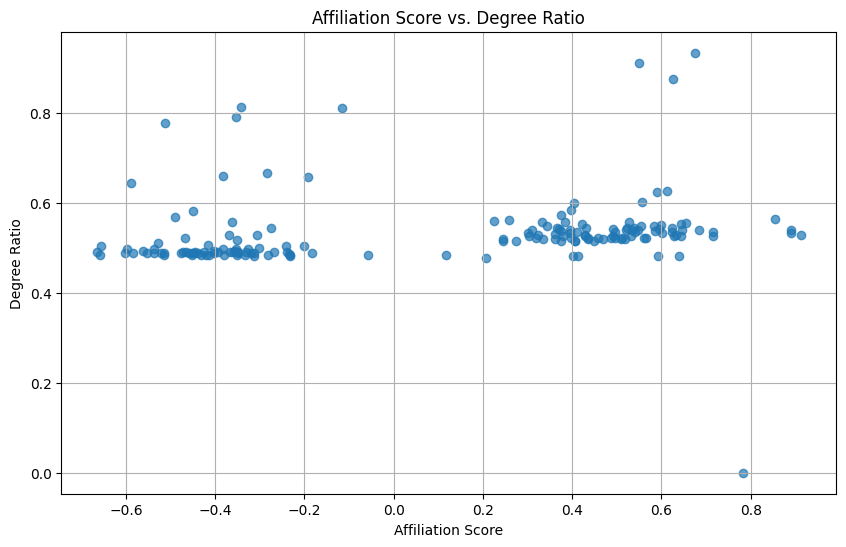

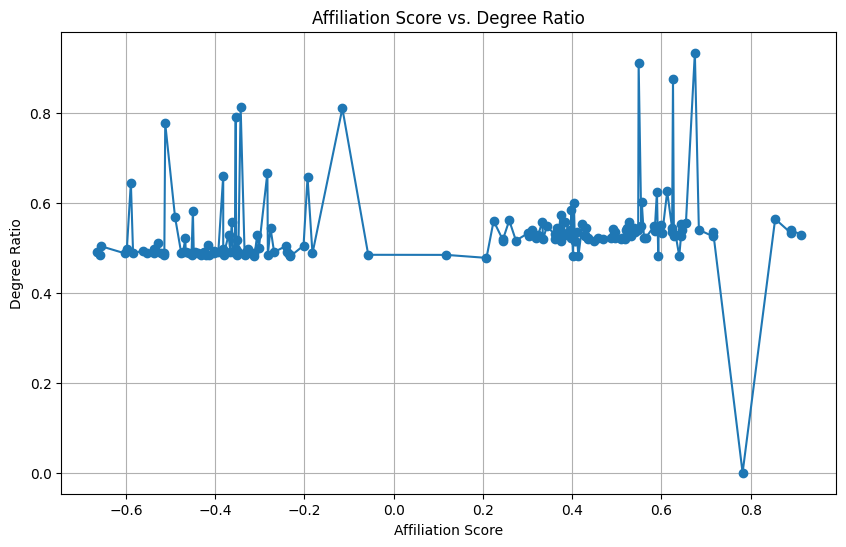

In [69]:
def affiliation_degree_dist(df_data):
    sorted_df = df_data.sort_values(by='affiliation_score')
    plt.figure(figsize=(10, 6))  # Set the figure size
    plt.scatter(sorted_df['affiliation_score'], sorted_df['degree_ratio'], alpha=0.7)  # alpha for transparency
    plt.title('Affiliation Score vs. Degree Ratio')
    plt.xlabel('Affiliation Score')
    plt.ylabel('Degree Ratio')
    plt.grid(True)  # Enable grid for better readability
    plt.show()
    plt.figure(figsize=(10, 6))
    plt.plot(sorted_df['affiliation_score'], sorted_df['degree_ratio'], marker='o', linestyle='-')  # 'o' for points
    plt.title('Affiliation Score vs. Degree Ratio')
    plt.xlabel('Affiliation Score')
    plt.ylabel('Degree Ratio')
    plt.grid(True)
    plt.show()

affiliation_degree_dist(df_data)

In [70]:
# Set 'current_twitter_name' as the index if it isn't already
# df_data.set_index('current_twitter_name', inplace=True)

# Add degree_ratio to each node in the graph
for node in G.nodes():
    G.nodes[node]['degree_ratio'] = df_data[df_data['current_twitter_name'] == node]['degree_ratio'].values[0]


In [ ]:

def calculate_neighbour_degree_ratio(node, graph, node_to_community):
    # Get neighbors of the node
    neighbors = list(graph.neighbors(node))
    print(node, neighbors)
    if not neighbors:
        return 0  # Return 0 if there are no neighbors to avoid division by zero
    
    # Sum of degree ratios for neighbors in the same community
    same_community_sum = sum(graph.nodes[neighbor]['degree_ratio'] for neighbor in neighbors 
                             if node_to_community[neighbor] == node_to_community[node])
    
    # Sum of degree ratios for all neighbors
    total_sum = sum(graph.nodes[neighbor]['degree_ratio'] for neighbor in neighbors)
    
    # Calculate the ratio
    return same_community_sum / total_sum if total_sum != 0 else 0




SpeakerRyan ['michelebachmann', 'EricCantor', 'keithellison', 'jasoninthehouse', 'reptomprice', 'repkarenbass', 'RepJamesClyburn', 'aaronschock', 'roslehtinen', 'stevekingia', 'cathymcmorris', 'vernbuchanan', 'jim_jordan', 'cbrangel', 'reppeteking', 'danarohrabacher', 'repjoebarton', 'michaelcburgess', 'DrPhilGingrey', 'peterroskam', 'robwittman', 'chairmanmckeon', 'patrickmchenry', 'tomrooney', 'KristiNoem', 'repsteveisrael', 'repshimkus', 'randy_forbes', 'PaulBrounforGA', 'repmikehonda', 'virginiafoxx', 'repmikecoffman', 'janschakowsky', 'repkenmarchant', 'ErikPaulsen', 'repdonnaedwards', 'askgeorge', 'congressmandan', 'judgecarter', 'greggharper', 'repraulgrijalva', 'chelliepingree', 'frankpallone', 'BHigginsBflo', 'repgusbilirakis', 'repreneeellmers', 'repkevinbrady', 'repwalterjones', 'peteolson', 'jackkingston', 'judgetedpoe', 'ShusterForPA9', 'repgwenmoore', 'jefffortenberry', 'repgregwalden', 'repmikerogersal', 'SenLummis', 'rephankjohnson', 'repmikequigley', 'rosadelauro', 'ca

In [ ]:
def calculate_neighbour2_degree_ratio(node, graph, node_to_community):
    # Get neighbors of the node
    neighbors = list(graph.neighbors(node))
    print(node, neighbors)
    if not neighbors:
        return 0  # Return 0 if there are no neighbors to avoid division by zero
    
    # Sum of degree ratios for neighbors in the same community
    same_community_sum = sum(graph.nodes[neighbor]['degree_ratio'] for neighbor in neighbors 
                             if node_to_community[neighbor] == node_to_community[node])
    
    
    # Sum of degree ratios for all neighbors
    total_sum = sum(graph.nodes[neighbor]['degree_ratio'] for neighbor in neighbors)
    
    different_community_sum = total_sum - same_community_sum
    
    # Calculate the ratio
    return (same_community_sum - different_community_sum) / total_sum if total_sum != 0 else 0

In [ ]:
def calculate_average_neighbour_degree(node, graph, node_to_community):
    #THIS IS THE KNN THING ON THE EMAIL, but including everyone (just how well connected neighbours are, not just the same community)
    # Get neighbors of the node
    neighbors = list(graph.neighbors(node))
    print(node, neighbors)
    if not neighbors:
        return 0  # Return 0 if there are no neighbors to avoid division by zero
    
    total_neighbor_degrees = sum(graph.degree(neighbor) for neighbor in neighbors)

    # Calculate the average degree of neighbors
    average_neighbor_degree = total_neighbor_degrees / len(neighbors) if neighbors else 0
    
    return average_neighbor_degree

In [ ]:
def calculate_average_same_comm_neighbour_degree(node, graph, node_to_community):
    # Get neighbors of the node
    neighbors = list(graph.neighbors(node))
    print(node, neighbors)  # This prints the node and its neighbors for debugging

    # Filter neighbors to include only those in the same community as the node
    same_community_neighbors = [neighbor for neighbor in neighbors if node_to_community[neighbor] == node_to_community[node]]

    if not same_community_neighbors:
        return 0  # Return 0 if there are no same-community neighbors to avoid division by zero

    # Sum the degrees of these same-community neighbors
    total_neighbor_degrees = sum(graph.degree(neighbor) for neighbor in same_community_neighbors)

    # Calculate the average degree of these neighbors
    average_neighbor_degree = total_neighbor_degrees / len(same_community_neighbors) if len(same_community_neighbors)>0 else 0

    return average_neighbor_degree


In [ ]:
df_data

,current_twitter_name,party,complete_following,following,affiliation_score,degree_ratio,final_degree_ratio,neighbour_degree_ratio,final_neighbour_degree_ratio
1,SpeakerRyan,R,"[DarrellIssa, WaysandMeansGOP, cathymcmorris, ...","[DarrellIssa, WaysandMeansGOP, RepKevinBrady, ...",0.969697,0.601562,0.601562,0.626227,0.626227
2,SpeakerPelosi,D,"[RepAdamSchiff, VP, RepJeffries, FLOTUS, RepSw...","[RepAdamSchiff, VP, RepJeffries, FLOTUS, RepSw...",-0.885246,0.568182,-0.568182,0.559444,-0.559444
3,michelebachmann,R,"[DavidLimbaugh, RedState, Heritage, ScottWalke...","[DavidLimbaugh, RedState, Heritage, ScottWalke...",0.965217,0.548611,0.548611,0.572830,0.572830
4,dwstweets,D,"[donnabrazile, Eugene_Robinson, JaredEMoskowit...","[donnabrazile, Eugene_Robinson, JaredEMoskowit...",-0.878049,0.506667,-0.506667,0.497455,-0.497455
5,EricCantor,R,"[EWErickson, foxnewspolitics, SpeakerBoehner, ...","[EWErickson, foxnewspolitics, SpeakerBoehner, ...",0.976000,0.518519,0.518519,0.537250,0.537250
...,...,...,...,...,...,...,...,...,...
176,stabenow,D,"[SenStabenow, SenGaryPeters, gretchenwhitmer, ...","[SenStabenow, SenGaryPeters, gretchenwhitmer, ...",-0.643939,0.813333,-0.813333,0.806193,-0.806193
179,sen_joemanchin,D,"[SenatorSinema, lisamurkowski, WVGovernor, Sen...","[SenatorSinema, WVGovernor, SenCapito, SenJoni...",-0.584615,0.484277,-0.484277,0.471763,-0.471763
180,sendancoats,R,"[AttyAbdul, lisamurkowski, nkellyIN, marybschn...","[AttyAbdul, nkellyIN, marybschneider, camsavag...",0.707692,0.537415,0.537415,0.558932,0.558932
181,mcconnellpress,R,"[LeaderMcConnell, RyanQuarlesKY, KYGOP, SenJoh...","[LeaderMcConnell, KYGOP, SenJohnThune, JamesCo...",0.628788,0.598425,0.598425,0.620881,0.620881


In [ ]:
from scipy.stats import rankdata


df_data['final_degree_ratio_rank'] = rankdata(df_data['final_degree_ratio'], method='average')  # Ranking the degree_ratio
df_data['final_neighbour_degree_ratio_rank'] = rankdata(df_data['final_neighbour_degree_ratio'], method='average')  # Ranking the degree_ratio

df_data['ground_truth_rank'] = rankdata(df_data['affiliation_score'], method='average')  # Ranking the ground truth

In [ ]:
republican_df = df_data[df_data['party'] == 'R']
democratic_df = df_data[df_data['party'] == 'D']

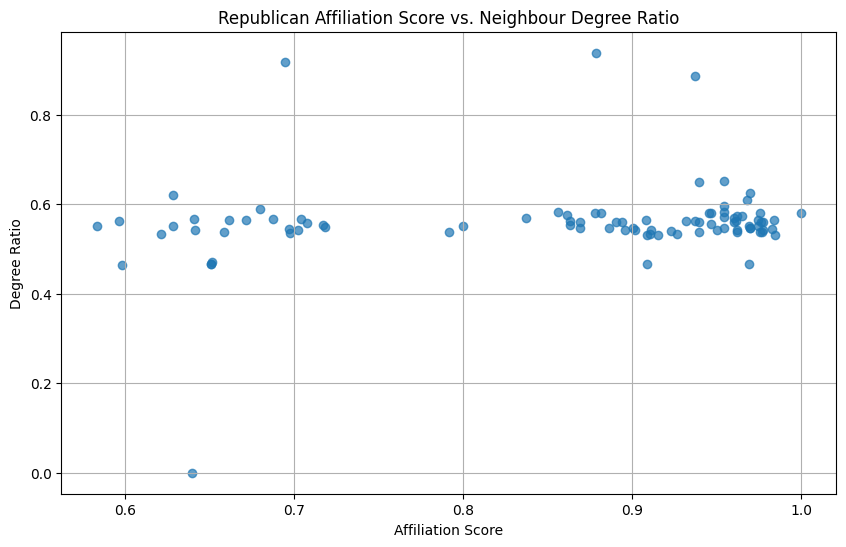

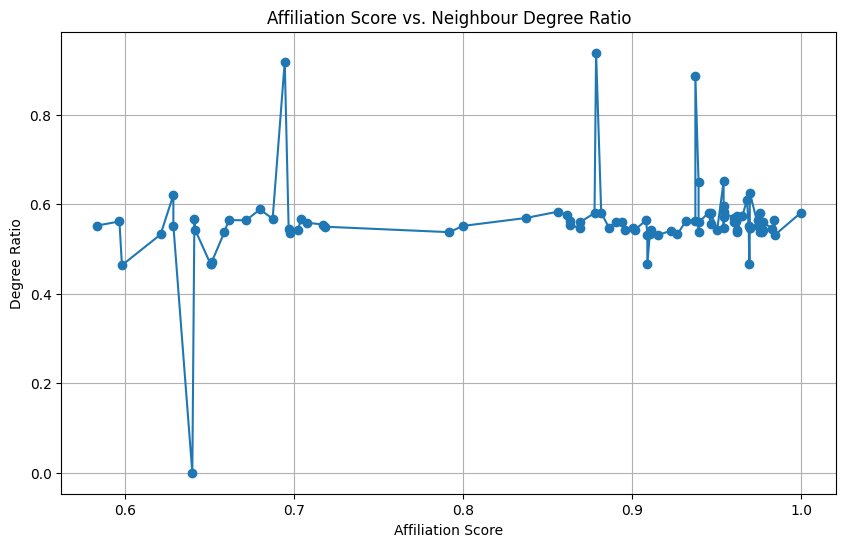

In [ ]:
def affiliation_degree_dist(df_data, name):
    sorted_df = df_data.sort_values(by='affiliation_score')
    plt.figure(figsize=(10, 6))  # Set the figure size
    plt.scatter(sorted_df['affiliation_score'], sorted_df['final_neighbour_degree_ratio'], alpha=0.7)  # alpha for transparency
    title_name = name + ' Affiliation Score vs. Neighbour Degree Ratio'
    plt.title(title_name)
    plt.xlabel('Affiliation Score')
    plt.ylabel('Degree Ratio')
    plt.grid(True)  # Enable grid for better readability
    plt.show()
    plt.figure(figsize=(10, 6))
    plt.plot(sorted_df['affiliation_score'], sorted_df['final_neighbour_degree_ratio'], marker='o', linestyle='-')  # 'o' for points
    plt.title('Affiliation Score vs. Neighbour Degree Ratio')
    plt.xlabel('Affiliation Score')
    plt.ylabel('Degree Ratio')
    plt.grid(True)
    plt.show()

affiliation_degree_dist(republican_df, "Republican")

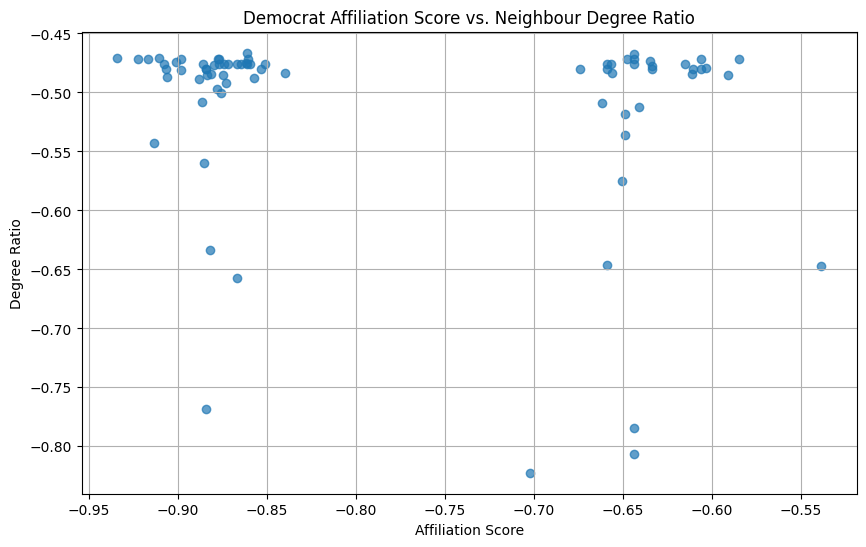

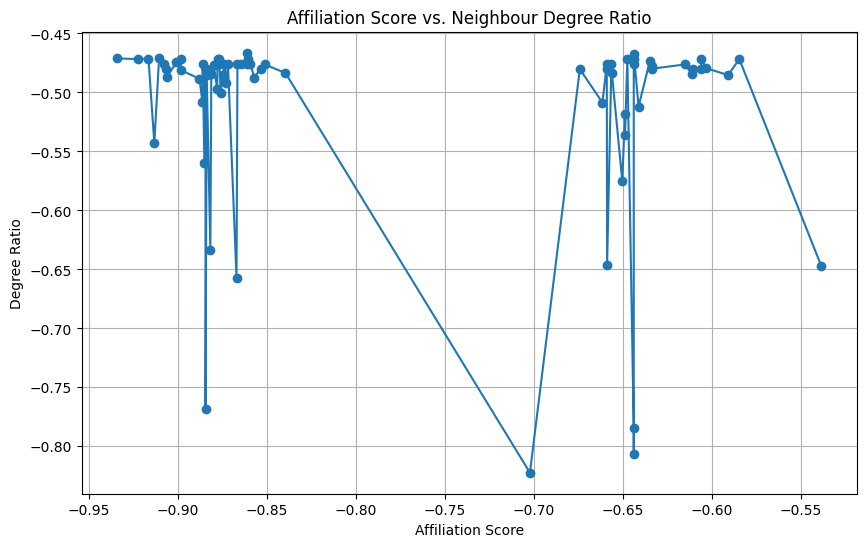

In [ ]:
affiliation_degree_dist(democratic_df, "Democrat")

In [ ]:
n_correlation = republican_df['affiliation_score'].corr(republican_df['final_neighbour_degree_ratio'], method='pearson')
d_correlation = republican_df['affiliation_score'].corr(republican_df['final_degree_ratio'], method='pearson')

print(f"Republican Pearson correlation between affiliation score and degree ratio: {d_correlation}")
print(f"Republican Pearson correlation between affiliation score and neighbour degree ratio: {n_correlation}")

n_correlation = republican_df['affiliation_score'].corr(republican_df['final_neighbour_degree_ratio'], method='spearman')
d_correlation = republican_df['affiliation_score'].corr(republican_df['final_degree_ratio'], method='spearman')

print(f"Republican Spearman correlation between affiliation score and degree ratio: {d_correlation}")
print(f"Republican Spearman correlation between affiliation score and neighbour degree ratio: {n_correlation}")


Republican Pearson correlation between affiliation score and degree ratio: 0.1387213498187518
Republican Pearson correlation between affiliation score and neighbour degree ratio: 0.17028990280588543
Republican Spearman correlation between affiliation score and degree ratio: 0.09058865826916548
Republican Spearman correlation between affiliation score and neighbour degree ratio: 0.11703758577405324


In [ ]:
n_correlation = democratic_df['affiliation_score'].corr(democratic_df['final_neighbour_degree_ratio'], method='pearson')
d_correlation = democratic_df['affiliation_score'].corr(democratic_df['final_degree_ratio'], method='pearson')

print(f"Democrat Pearson correlation between affiliation score and degree ratio: {d_correlation}")
print(f"Democrat Pearson correlation between affiliation score and neighbour degree ratio: {n_correlation}")

n_correlation = democratic_df['affiliation_score'].corr(democratic_df['final_neighbour_degree_ratio'], method='spearman')
d_correlation = democratic_df['affiliation_score'].corr(democratic_df['final_degree_ratio'], method='spearman')

print(f"Democrat Spearman correlation between affiliation score and degree ratio: {d_correlation}")
print(f"Democrat Spearman correlation between affiliation score and neighbour degree ratio: {n_correlation}")



Democrat Pearson correlation between affiliation score and degree ratio: -0.16648732587469972
Democrat Pearson correlation between affiliation score and neighbour degree ratio: -0.16884541783263352
Democrat Spearman correlation between affiliation score and degree ratio: -0.06537362281494327
Democrat Spearman correlation between affiliation score and neighbour degree ratio: -0.09218402288708674


In [ ]:
from scipy.stats import kendalltau

kendall_tau, kt_p_value = kendalltau(republican_df['final_degree_ratio'], republican_df['affiliation_score'])
print("Republican Kendall's tau between affiliation score and degree ratio:", kendall_tau, "P-value:", kt_p_value)

kendall_tau, kt_p_value = kendalltau(republican_df['final_neighbour_degree_ratio'], republican_df['affiliation_score'])
print("Republican Kendall's tau between affiliation score and neighbour degree ratio:", kendall_tau, "P-value:", kt_p_value)

Republican Kendall's tau between affiliation score and degree ratio: 0.05831007683599233 P-value: 0.41630507865956956
Republican Kendall's tau between affiliation score and neighbour degree ratio: 0.07567970406357186 P-value: 0.28937511873645516


In [ ]:
from scipy.stats import kendalltau

kendall_tau, kt_p_value = kendalltau(democratic_df['final_degree_ratio'], democratic_df['affiliation_score'])
print("Democrat Kendall's tau between affiliation score and degree ratio:", kendall_tau, "P-value:", kt_p_value)

kendall_tau, kt_p_value = kendalltau(democratic_df['final_neighbour_degree_ratio'], democratic_df['affiliation_score'])
print("Democrat Kendall's tau between affiliation score and neighbour degree ratio:", kendall_tau, "P-value:", kt_p_value)

Democrat Kendall's tau between affiliation score and degree ratio: -0.05370453115937414 P-value: 0.5145313352483258
Democrat Kendall's tau between affiliation score and neighbour degree ratio: -0.06107681233556565 P-value: 0.4508818210224107


Text(0.5, 0, 'Neighbour Degree Ratio')

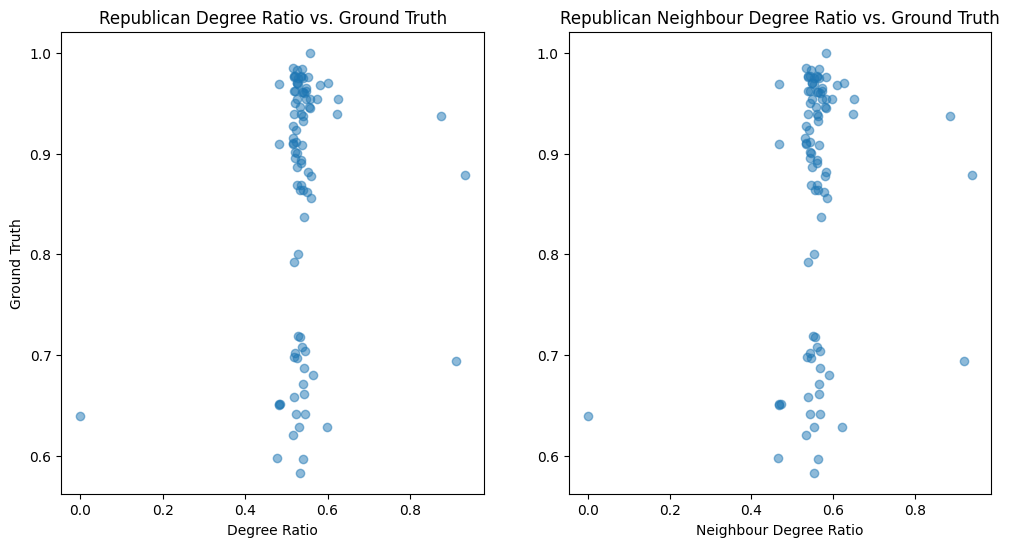

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(republican_df['final_degree_ratio'], republican_df['affiliation_score'], alpha=0.5)
plt.title('Republican Degree Ratio vs. Ground Truth')
plt.xlabel('Degree Ratio')
plt.ylabel('Ground Truth')

plt.subplot(1, 2, 2)
plt.scatter(republican_df['final_neighbour_degree_ratio'], republican_df['affiliation_score'], alpha=0.5)
plt.title('Republican Neighbour Degree Ratio vs. Ground Truth')
plt.xlabel('Neighbour Degree Ratio')


Text(0.5, 0, 'Neighbour Degree Ratio')

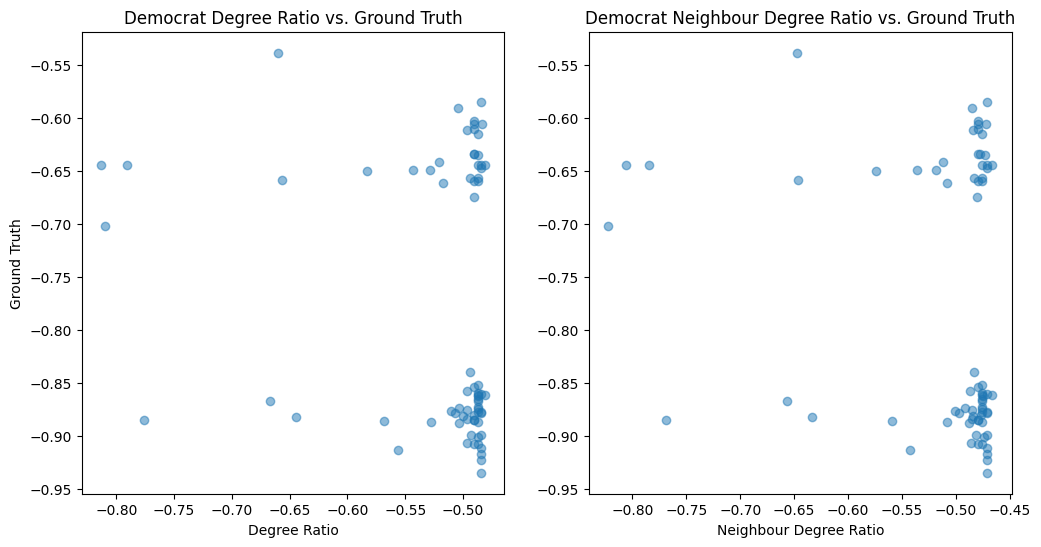

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(democratic_df['final_degree_ratio'], democratic_df['affiliation_score'], alpha=0.5)
plt.title('Democrat Degree Ratio vs. Ground Truth')
plt.xlabel('Degree Ratio')
plt.ylabel('Ground Truth')

plt.subplot(1, 2, 2)
plt.scatter(democratic_df['final_neighbour_degree_ratio'], democratic_df['affiliation_score'], alpha=0.5)
plt.title('Democrat Neighbour Degree Ratio vs. Ground Truth')
plt.xlabel('Neighbour Degree Ratio')


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import rankdata
# Rank data according to 'degree_ratio' and 'ground_truth'
df_data['final_degree_ratio_rank'] = rankdata(df_data['final_degree_ratio'], method='average')  # Ranking the degree_ratio
df_data['final_neighbour_degree_ratio_rank'] = rankdata(df_data['final_neighbour_degree_ratio'], method='average')  # Ranking the degree_ratio

df_data['ground_truth_rank'] = rankdata(df_data['affiliation_score'], method='average')  # Ranking the ground truth

# Calculate MSE of the ranks
mse_ranks = np.mean((df_data['final_degree_ratio_rank'] - df_data['ground_truth_rank']) ** 2)
print("MSE of the ranks:", mse_ranks)


MSE of the ranks: 1114.844512195122


In [ ]:
def top_k_accuracy(df, metric_rank, truth_rank, k):
    # Get top K indices from both rankings
    top_k_metric = set(df.nlargest(k, metric_rank).index)
    top_k_truth = set(df.nlargest(k, truth_rank).index)

    # Calculate the intersection
    correct_top_k = len(top_k_metric & top_k_truth)
    accuracy_top_k = correct_top_k / k
    return accuracy_top_k

# Example usage for top 10 and top 20
accuracy_top_10 = top_k_accuracy(df_data, 'final_degree_ratio_rank', 'ground_truth_rank', 42)
accuracy_top_20 = top_k_accuracy(df_data, 'final_degree_ratio_rank', 'ground_truth_rank', 20)

print("Accuracy of Top 10 rankings:", accuracy_top_10)
print("Accuracy of Top 20 rankings:", accuracy_top_20)


Accuracy of Top 10 rankings: 0.5476190476190477
Accuracy of Top 20 rankings: 0.25


In [ ]:
tau, p_value = kendalltau(df_data['final_degree_ratio_rank'], df_data['ground_truth_rank'])
print(f"Kendall's Tau-b: {tau}, p-value: {p_value}")

Kendall's Tau-b: 0.5093385959815422, p-value: 8.306148436475151e-22


In [ ]:
n_correlation = democratic_df['affiliation_score'].corr(democratic_df['final_neighbour_degree_ratio'], method='pearson')
d_correlation = democratic_df['affiliation_score'].corr(democratic_df['final_degree_ratio'], method='pearson')

print(f"Democrat Pearson correlation between ground truth rank and degree ratio: {d_correlation}")
print(f"Democrat Pearson correlation between ground truth rank and neighbour degree ratio: {n_correlation}")

n_correlation = democratic_df['ground_truth_rank'].corr(democratic_df['final_neighbour_degree_ratio_rank'], method='spearman')
d_correlation = democratic_df['ground_truth_rank'].corr(democratic_df['final_degree_ratio_rank'], method='spearman')

print(f"Democrat Spearman correlation between ground truth rank and degree ratio rank: {d_correlation}")
print(f"Democrat Spearman correlation between ground truth rank and neighbour degree ratio rank: {n_correlation}")



Democrat Pearson correlation between ground truth rank and degree ratio: -0.16648732587469972
Democrat Pearson correlation between ground truth rank and neighbour degree ratio: -0.16884541783263352
Democrat Spearman correlation between ground truth rank and degree ratio rank: -0.06537362281494327
Democrat Spearman correlation between ground truth rank and neighbour degree ratio rank: -0.09218402288708674


In [ ]:
n_correlation = republican_df['affiliation_score'].corr(republican_df['final_neighbour_degree_ratio'], method='pearson')
d_correlation = republican_df['affiliation_score'].corr(republican_df['final_degree_ratio'], method='pearson')

print(f"Republican Pearson correlation between ground truth rank and degree ratio: {d_correlation}")
print(f"Republican Pearson correlation between ground truth rank and neighbour degree ratio: {n_correlation}")

n_correlation = republican_df['ground_truth_rank'].corr(republican_df['final_neighbour_degree_ratio_rank'], method='spearman')
d_correlation = republican_df['ground_truth_rank'].corr(republican_df['final_degree_ratio_rank'], method='spearman')

print(f"Republican Spearman correlation between ground truth rank and degree ratio: {d_correlation}")
print(f"Republican Spearman correlation between ground truth rank and neighbour degree ratio: {n_correlation}")



Republican Pearson correlation between ground truth rank and degree ratio: 0.1387213498187518
Republican Pearson correlation between ground truth rank and neighbour degree ratio: 0.17028990280588543
Republican Spearman correlation between ground truth rank and degree ratio: 0.09058865826916548
Republican Spearman correlation between ground truth rank and neighbour degree ratio: 0.11703758577405324


Text(0.5, 0, 'Neighbour Degree Ratio Ranks')

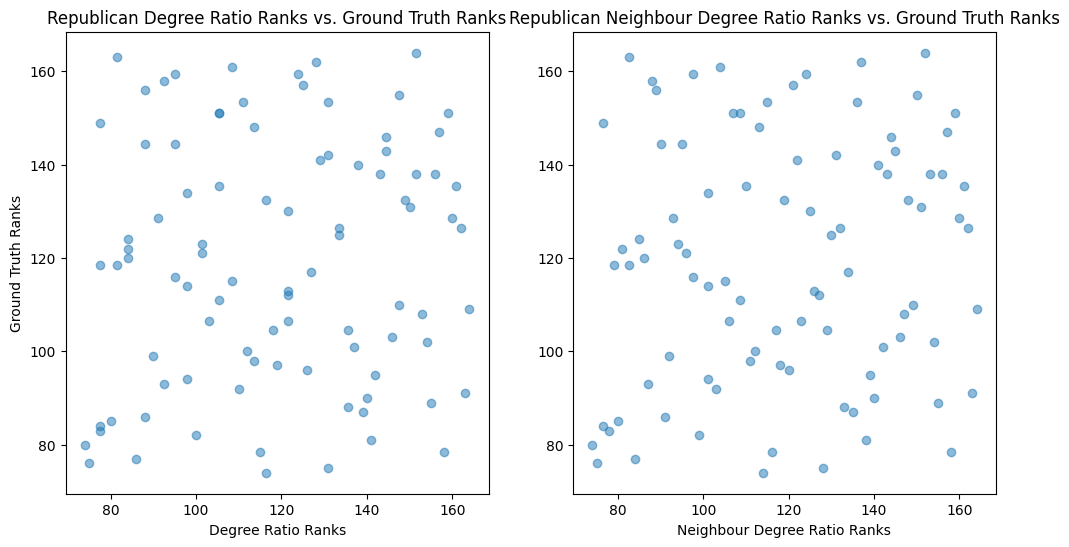

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(republican_df['final_degree_ratio_rank'], republican_df['ground_truth_rank'], alpha=0.5)
plt.title('Republican Degree Ratio Ranks vs. Ground Truth Ranks')
plt.xlabel('Degree Ratio Ranks')
plt.ylabel('Ground Truth Ranks')

plt.subplot(1, 2, 2)
plt.scatter(republican_df['final_neighbour_degree_ratio_rank'], republican_df['ground_truth_rank'], alpha=0.5)
plt.title('Republican Neighbour Degree Ratio Ranks vs. Ground Truth Ranks')
plt.xlabel('Neighbour Degree Ratio Ranks')


Text(0.5, 0, 'Neighbour Degree Ratio Ranks')

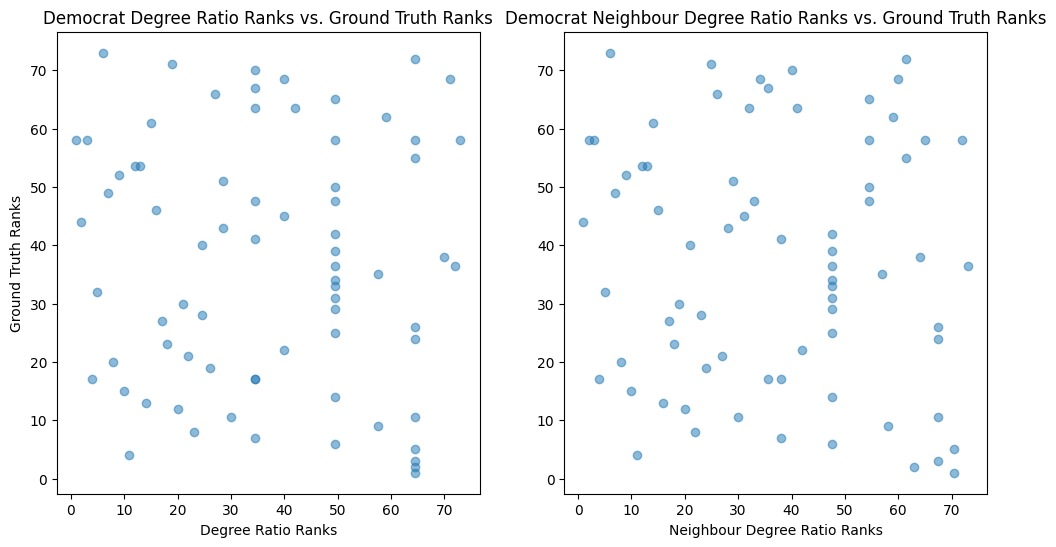

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(democratic_df['final_degree_ratio_rank'], democratic_df['ground_truth_rank'], alpha=0.5)
plt.title('Democrat Degree Ratio Ranks vs. Ground Truth Ranks')
plt.xlabel('Degree Ratio Ranks')
plt.ylabel('Ground Truth Ranks')

plt.subplot(1, 2, 2)
plt.scatter(democratic_df['final_neighbour_degree_ratio_rank'], democratic_df['ground_truth_rank'], alpha=0.5)
plt.title('Democrat Neighbour Degree Ratio Ranks vs. Ground Truth Ranks')
plt.xlabel('Neighbour Degree Ratio Ranks')


In [ ]:
n_correlation = df_data['ground_truth_rank'].corr(df_data['final_neighbour_degree_ratio_rank'], method='pearson')
d_correlation = df_data['ground_truth_rank'].corr(df_data['final_degree_ratio_rank'], method='pearson')

print(f"Pearson correlation between affiliation score and degree ratio: {d_correlation}")
print(f"Pearson correlation between affiliation score and neighbour degree ratio: {n_correlation}")


Pearson correlation between affiliation score and degree ratio: 0.7511507001003949
Pearson correlation between affiliation score and neighbour degree ratio: 0.752996410121949


In [ ]:
n_correlation = df_data['ground_truth_rank'].corr(df_data['final_neighbour_degree_ratio_rank'], method='spearman')
d_correlation = df_data['ground_truth_rank'].corr(df_data['final_degree_ratio_rank'], method='spearman')

print(f"Spearman correlation between affiliation score and degree ratio: {d_correlation}")
print(f"Spearman correlation between affiliation score and neighbour degree ratio: {n_correlation}")


Spearman correlation between affiliation score and degree ratio: 0.7511507001003949
Spearman correlation between affiliation score and neighbour degree ratio: 0.7529964101219491
